<a href="https://colab.research.google.com/github/TJsnap7355/Final-Project-C-/blob/main/CCFD_Computer_Security_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#CC Data (ensure this is the file name for the original file)
from google.colab import files
uploaded = files.upload()

Saving CC Data.xlsx to CC Data (1).xlsx


In [ ]:
#CC Data + Fraud (ensure this is the file name for the augmented file)
from google.colab import files
uploaded = files.upload()

Saving CC Data + Fraud.xlsx to CC Data + Fraud.xlsx


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, average_precision_score

from imblearn.over_sampling import SMOTE, RandomOverSampler

# Load the datasets
print("Loading datasets...")
df_original = pd.read_excel('CC Data.xlsx')
df_extended = pd.read_excel('CC Data + Fraud.xlsx')

print(f"Original Data Shape: {df_original.shape}")
print(f"Extended Data Shape: {df_extended.shape}")

Loading datasets...
Original Data Shape: (284807, 31)
Extended Data Shape: (298555, 31)


In [ ]:
# Clean datasets by removing missing values
# Alternatively, we could fill them, but dropping is a safe default if missingness is low.
df_original_clean = df_original.dropna()
df_extended_clean = df_extended.dropna()

print(f"Original Data Shape after cleaning: {df_original_clean.shape}")
print(f"Extended Data Shape after cleaning: {df_extended_clean.shape}")

Original Data Shape after cleaning: (284807, 31)
Extended Data Shape after cleaning: (298555, 31)


In [ ]:
from sklearn.preprocessing import StandardScaler

def scale_dataframe(df):
    # Identify numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # We typically don't scale binary target columns. Let's exclude common names for fraud targets.
    target_keywords = ['class', 'fraud', 'is_fraud', 'isfraud', 'target']
    cols_to_scale = [c for c in numeric_cols if c.lower() not in target_keywords]

    scaler = StandardScaler()
    df_scaled = df.copy()

    if len(cols_to_scale) > 0:
        df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df_scaled

df_original_scaled = scale_dataframe(df_original_clean)
df_extended_scaled = scale_dataframe(df_extended_clean)

print("Numeric features scaled successfully (excluding potential target variables).")

Numeric features scaled successfully (excluding potential target variables).


In [ ]:
# Split both datasets into 3 subsets (A, B, C) to simulate 3 banks
def split_into_three(df):
    # Shuffle the dataframe to ensure random distribution
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Calculate split indices
    n = len(df_shuffled)
    split1 = n // 3
    split2 = 2 * n // 3

    # Split into 3 subsets
    subset_A = df_shuffled.iloc[:split1]
    subset_B = df_shuffled.iloc[split1:split2]
    subset_C = df_shuffled.iloc[split2:]

    return subset_A, subset_B, subset_C

orig_A, orig_B, orig_C = split_into_three(df_original_scaled)
ext_A, ext_B, ext_C = split_into_three(df_extended_scaled)

print(f"Original Subsets sizes -> A: {len(orig_A)}, B: {len(orig_B)}, C: {len(orig_C)}")
print(f"Extended Subsets sizes -> A: {len(ext_A)}, B: {len(ext_B)}, C: {len(ext_C)}")

Original Subsets sizes -> A: 94935, B: 94936, C: 94936
Extended Subsets sizes -> A: 99518, B: 99518, C: 99519


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, average_precision_score
import pandas as pd

def train_and_evaluate(df, bank_name):
    # Identify the target column ('Class' or similar)
    target_col = [c for c in df.columns if c.lower() in ['class', 'fraud', 'is_fraud', 'target']][0]

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Split into train and test for evaluation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Initialize and train the Logistic Regression model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for PR-AUC

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)

    return {'Bank Model': bank_name, 'Accuracy': acc, 'Recall': recall, 'F1 Score': f1, 'PR-AUC': pr_auc}

### Understanding the Evaluation Metrics for Fraud Detection

When dealing with highly imbalanced data like credit card fraud (where 99.8% of transactions are legitimate and only 0.2% are fraud), standard metrics can be misleading. Here is what each metric means for our models:

*   **Accuracy:** The overall percentage of correct predictions.
    *   *In our data:* This metric is dangerously misleading. If a model just predicted "Not Fraud" for every single transaction, it would still achieve ~99.8% accuracy, but it would be completely useless for a bank. High accuracy is expected, but not sufficient.

*   **Recall (Sensitivity):** Out of all the *actual* fraudulent transactions, how many did the model successfully catch?
    *   *In our data:* This is arguably the most important metric. A low recall (like Bank C's original 44%) means the bank is missing more than half of the frauds, leading to massive financial losses. We want this to be as high as possible.

*   **F1 Score:** The harmonic mean of Precision (out of all predicted frauds, how many were real?) and Recall.
    *   *In our data:* It provides a single score that balances the need to catch frauds (Recall) with the need to avoid falsely declining legitimate customer transactions (Precision). A high F1 score means the model is good at catching fraud without making too many false accusations.

*   **PR-AUC (Precision-Recall Area Under the Curve):** Summarizes the trade-off between Precision and Recall across different decision thresholds.
    *   *In our data:* For highly imbalanced datasets, PR-AUC is much more informative than the standard ROC-AUC. A PR-AUC close to 1.0 (like we see in the Extended Dataset) means the model can maintain both high precision and high recall simultaneously, making it an excellent, robust fraud detector.
--------------------------------------------------------------------------------

In [ ]:
# Train and evaluate models on the Original Data Subsets
results_orig = []

print("Training models on Original Data subsets...")
results_orig.append(train_and_evaluate(orig_A, 'Bank A (Original)'))
results_orig.append(train_and_evaluate(orig_B, 'Bank B (Original)'))
results_orig.append(train_and_evaluate(orig_C, 'Bank C (Original)'))

df_orig = pd.DataFrame(results_orig)
print("\nOriginal Data Models Performance:")
display(df_orig)

Training models on Original Data subsets...

Original Data Models Performance:


,Bank Model,Accuracy,Recall,F1 Score,PR-AUC
0,Bank A (Original),0.999263,0.666667,0.740741,0.702988
1,Bank B (Original),0.999315,0.685714,0.786885,0.673813
2,Bank C (Original),0.998789,0.441176,0.566038,0.616833


In [ ]:
# Train and evaluate models on the Extended Data Subsets
results_ext = []

print("\nTraining models on Extended Data subsets...")
results_ext.append(train_and_evaluate(ext_A, 'Bank A (Extended)'))
results_ext.append(train_and_evaluate(ext_B, 'Bank B (Extended)'))
results_ext.append(train_and_evaluate(ext_C, 'Bank C (Extended)'))

df_ext = pd.DataFrame(results_ext)
print("\nExtended Data Models Performance:")
display(df_ext)


Training models on Extended Data subsets...

Extended Data Models Performance:


,Bank Model,Accuracy,Recall,F1 Score,PR-AUC
0,Bank A (Extended),0.998794,0.978216,0.987435,0.995441
1,Bank B (Extended),0.998694,0.973205,0.985885,0.994040
2,Bank C (Extended),0.999196,0.988433,0.991561,0.992790


**Original Dataset:** **High Variation and Missing Fraud**

When looking at the Original Data models (Banks A, B, and C):
*   Bank C only has a Recall of ~44.1%. This means it misses more than half of all fraudulent transactions!
*   Banks A and B do slightly better (Recall around 66% and 68%) but still let a significant amount of fraud slip through.
*   Because the data is highly imbalanced and split randomly, each bank might see different 'types' or 'amounts' of fraud, leading to highly variable and unreliable F1 Scores (56% to 78%).

**Extended Dataset:** **The Power of Representation**

When we look at the Extended Data (which injected synthetic fraud records to make the dataset more balanced):
*   All Banks (A, B, C) shoot up to over 97% Recall and 98% F1 Score.
*   The performance is extremely consistent across all three banks.
*   By providing enough representation of the minority class (fraud), the Logistic Regression model can properly learn the decision boundary.
----------------------------------------------------------------------------


**Conclusion:** The individual models trained on local, highly imbalanced original data struggle significantly with detecting fraud (low Recall). This perfectly sets up the motivation for advanced techniques like Federated Learning or data balancing (as seen in your Extended dataset) to help individual banks catch fraud more reliably without sharing raw data!

----------------------------------------------------------------------------

# Summary


1.   **Data Preparation:** Loaded the original and extended Kaggle credit card fraud datasets, handled missing values, scaled the numerical features, and split the data into 3 subsets (A, B, C) to simulate different banks.
2.  **Baseline Modeling:** Trained separate Logistic Regression models for each bank subset.
3.   **Evaluation & Comparison:** Evaluated all models using Accuracy, Recall, F1 Score, and PR-AUC. We compared the results and identified that models trained on the highly imbalanced original data struggled with Recall (missing actual fraud), whereas the extended (balanced) dataset yielded much better and more consistent performance across all simulated banks.




# **AFTER MIDTERM**

# Advanced Model Experiments [Oversampling / SMOTE]

In [ ]:
# OPTION B HELPERS (ISOLATED)
# These functions are kept separate from the original project pipeline
# so that Option B can be tested without interfering with the base code.

def get_target_col_optb(df):

    # Find the fraud target column by checking for common label names.
    return [c for c in df.columns if c.lower() in ['class', 'fraud', 'is_fraud', 'isfraud', 'target']][0]

def split_bank_train_test_optb(bank_df):
    target_col = get_target_col_optb(bank_df)


    # Separate predictors (X) from the fraud label (y).
    X = bank_df.drop(columns=[target_col])
    y = bank_df[target_col]

    # Split this bank's data into training and testing sets.
    # stratify=y preserves the fraud/non-fraud ratio in both sets.
    X_train_optb, X_test_optb, y_train_optb, y_test_optb = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return X_train_optb, X_test_optb, y_train_optb, y_test_optb, target_col

def augment_training_data_optb(X_train_optb, y_train_optb, method='smote', sampling_strategy=0.5):
    # Apply data balancing ONLY to the training set.
    if method == 'smote':          # SMOTE generates synthetic fraud points using nearest neighbors.
        sampler = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=2)
    elif method == 'oversample':   # RandomOverSampler simply duplicates minority samples.
        sampler = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
    else:
        raise ValueError("method must be 'smote' or 'oversample'")

    X_resampled_optb, y_resampled_optb = sampler.fit_resample(X_train_optb, y_train_optb)
    return X_resampled_optb, y_resampled_optb

def train_and_evaluate_presplit_optb(X_train_optb, y_train_optb, X_test_optb, y_test_optb, bank_name):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_optb, y_train_optb)

    # Make predictions on the untouched test set.
    y_pred = model.predict(X_test_optb)
    y_prob = model.predict_proba(X_test_optb)[:, 1]

    # Evaluate using the main fraud-detection metrics.
    acc = accuracy_score(y_test_optb, y_pred)
    recall = recall_score(y_test_optb, y_pred)
    f1 = f1_score(y_test_optb, y_pred)
    pr_auc = average_precision_score(y_test_optb, y_prob)

    return {
        'Bank Model': bank_name,
        'Accuracy': acc,
        'Recall': recall,
        'F1 Score': f1,
        'PR-AUC': pr_auc
    }

In [ ]:
print("\nApplying Option B to ORIGINAL bank splits...")

# Split each bank into local train/test
XA_train_optb, XA_test_optb, yA_train_optb, yA_test_optb, target_col_optb = split_bank_train_test_optb(orig_A)
XB_train_optb, XB_test_optb, yB_train_optb, yB_test_optb, _ = split_bank_train_test_optb(orig_B)
XC_train_optb, XC_test_optb, yC_train_optb, yC_test_optb, _ = split_bank_train_test_optb(orig_C)

# Apply SMOTE / oversampling ONLY to training sets
XA_train_aug_optb, yA_train_aug_optb = augment_training_data_optb(
    XA_train_optb, yA_train_optb, method='smote', sampling_strategy=0.5
)
XB_train_aug_optb, yB_train_aug_optb = augment_training_data_optb(
    XB_train_optb, yB_train_optb, method='smote', sampling_strategy=0.5
)
XC_train_aug_optb, yC_train_aug_optb = augment_training_data_optb(
    XC_train_optb, yC_train_optb, method='smote', sampling_strategy=0.5
)
# Display class counts before and after augmentation for Bank A
print("\nBank A original training class counts:")
print(yA_train_optb.value_counts())
print("Bank A augmented training class counts:")
print(pd.Series(yA_train_aug_optb).value_counts())

print("\nBank B original training class counts:")
print(yB_train_optb.value_counts())

print("\nBank C original training class counts:")
print(yC_train_optb.value_counts())


Applying Option B to ORIGINAL bank splits...

Bank A original training class counts:
Class
0    75829
1      119
Name: count, dtype: int64
Bank A augmented training class counts:
Class
0    75829
1    37914
Name: count, dtype: int64

Bank B original training class counts:
Class
0    75810
1      138
Name: count, dtype: int64

Bank C original training class counts:
Class
0    75812
1      136
Name: count, dtype: int64


In [ ]:
results_option_b = []

print("\nTraining models on Option B bank-local augmented training sets...")
results_option_b.append(
    train_and_evaluate_presplit_optb(XA_train_aug_optb, yA_train_aug_optb, XA_test_optb, yA_test_optb, 'Bank A (Option B)')
)
results_option_b.append(
    train_and_evaluate_presplit_optb(XB_train_aug_optb, yB_train_aug_optb, XB_test_optb, yB_test_optb, 'Bank B (Option B)')
)
results_option_b.append(
    train_and_evaluate_presplit_optb(XC_train_aug_optb, yC_train_aug_optb, XC_test_optb, yC_test_optb, 'Bank C (Option B)')
)

df_option_b = pd.DataFrame(results_option_b)

print("\nOption B Models Performance:")
display(df_option_b)


Training models on Option B bank-local augmented training sets...

Option B Models Performance:


,Bank Model,Accuracy,Recall,F1 Score,PR-AUC
0,Bank A (Option B),0.985148,0.900000,0.160714,0.750788
1,Bank B (Option B),0.985412,0.771429,0.163142,0.635552
2,Bank C (Option B),0.991679,0.852941,0.268519,0.529391


In [ ]:
print("\nComparing Original vs Extended vs Option B...")
comparison_df = pd.concat([df_orig, df_ext, df_option_b], ignore_index=True)
display(comparison_df)


Comparing Original vs Extended vs Option B...


,Bank Model,Accuracy,Recall,F1 Score,PR-AUC
0,Bank A (Original),0.999263,0.666667,0.740741,0.702988
1,Bank B (Original),0.999315,0.685714,0.786885,0.673813
2,Bank C (Original),0.998789,0.441176,0.566038,0.616833
3,Bank A (Extended),0.998794,0.978216,0.987435,0.995441
4,Bank B (Extended),0.998694,0.973205,0.985885,0.994040
5,Bank C (Extended),0.999196,0.988433,0.991561,0.992790
6,Bank A (Option B),0.985148,0.900000,0.160714,0.750788
7,Bank B (Option B),0.985412,0.771429,0.163142,0.635552
8,Bank C (Option B),0.991679,0.852941,0.268519,0.529391


# Confusion Matrix

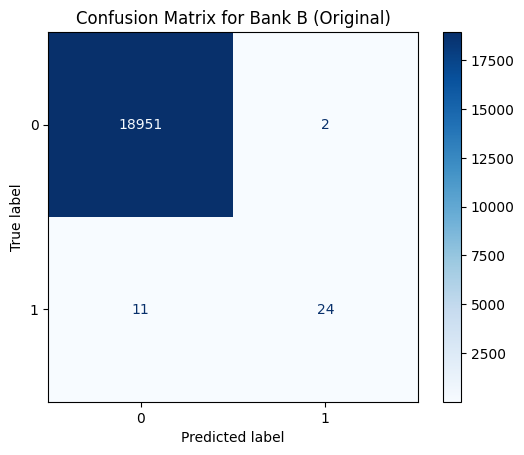

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Re-split orig_B to get the test set and train a model

def get_model_and_test_data(df):
    target_col = [c for c in df.columns if c.lower() in ['class', 'fraud', 'is_fraud', 'target']][0]
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model, X_test, y_test


model_orig_B, X_test_orig_B, y_test_orig_B = get_model_and_test_data(orig_B)

y_pred_orig_B = model_orig_B.predict(X_test_orig_B)

cm = confusion_matrix(y_test_orig_B, y_pred_orig_B)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_orig_B.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Bank B (Original)')
plt.show()

This code focuses on evaluating the performance of a model trained solely on Bank B's original (highly imbalanced) dataset by visualizing its predictions using a Confusion Matrix.

Here is a step-by-step breakdown:

1. Imports: It imports the necessary tools from scikit-learn to calculate and display the confusion matrix, along with matplotlib for plotting the graph.

2. Helper Function (get_model_and_test_data): It defines a function that takes a dataset, splits it into features (X) and the target variable (y), and then splits the data into 80% training and 20% testing sets. It trains a Logistic Regression model on the training set and returns the trained model along with the testing data so we can evaluate it.

3. Training Bank B's Model: It calls this function using orig_B (Bank B's isolated, original data) to get a trained local model and the test data for Bank B.

4. Making Predictions: It uses the trained model to predict whether the transactions in the test set (X_test_orig_B) are fraudulent or legitimate.

5. Creating the Confusion Matrix: It calculates the confusion matrix, which compares the model's predictions against the actual true labels. This allows us to see exactly how many transactions were correctly identified (True Positives/Negatives) and how many were misclassified (False Positives/Negatives).

6. Plotting: Finally, it uses ConfusionMatrixDisplay and matplotlib to draw a nice visual heatmap (using a blue color scale) of the confusion matrix so you can easily interpret the results.

The matrix has four quadrants representing the actual vs. predicted classifications (0 is Legitimate, 1 is Fraud):

- 18,951 (Top-Left) - True Negatives: The model correctly identified 18,951 transactions as legitimate.
- 24 (Bottom-Right) - True Positives: The model successfully caught 24 actual fraudulent transactions.
- 2 (Top-Right) - False Positives: The model incorrectly flagged 2 legitimate transactions as fraud. In the real world, this means a customer's card might be temporarily blocked for a safe purchase.
- 11 (Bottom-Left) - False Negatives: The model completely missed 11 fraudulent transactions, labeling them as legitimate.

Why this matters: The "11" is the most critical number here. Even though the model correctly handled nearly 19,000 legitimate transactions, it missed almost a third of the actual frauds (11 missed vs 24 caught). This is a perfect visual representation of why high accuracy can be misleading and why we need better strategies (like balancing data or using Federated Learning) to improve our Recall!

### Simulating Federated Learning (FedAvg)

In this section, we will implement the 4 steps of a standard Federated Learning round:
1. **Global Model Initialization**: We define the architecture for the global model.
2. **Local Training**: Each bank trains a model exclusively on its own local, independent dataset.
3. **Model Updates**: Instead of sharing raw data, each bank extracts its model's learned weights (coefficients and intercepts) and sends them to the central server.
4. **Aggregation**: The central server averages the weights to create an updated, smarter global model.

Training local model at Bank A...
Training local model at Bank B...
Training local model at Bank C...

Aggregating weights at the Central Server (FedAvg)...

Evaluating the Aggregated Global Model on all test data...
Global Model Accuracy: 0.9991
Global Model Recall:   0.5657
Global Model F1 Score: 0.6747
Global Model PR-AUC:   0.6944


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


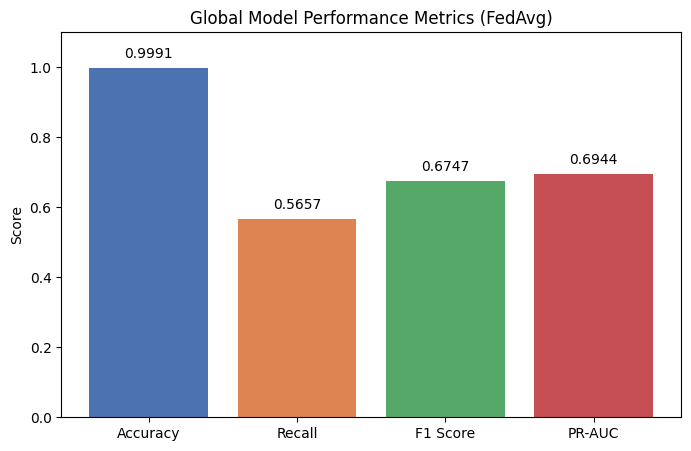

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, average_precision_score
import matplotlib.pyplot as plt

# Helper function to split data into features (X) and target (y)
def get_X_y(df):
    target_col = [c for c in df.columns if c.lower() in ['class', 'fraud', 'is_fraud', 'target']][0]
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split local data for each bank
XA_train, XA_test, yA_train, yA_test = get_X_y(orig_A)
XB_train, XB_test, yB_train, yB_test = get_X_y(orig_B)
XC_train, XC_test, yC_train, yC_test = get_X_y(orig_C)

# Create a combined test set to evaluate the Global Model fairly
X_global_test = pd.concat([XA_train, XB_train, XC_train]) # We use the training parts for local training
X_global_test = pd.concat([XA_test, XB_test, XC_test])
y_global_test = pd.concat([yA_test, yB_test, yC_test])

# Step 2: Train locally with independent data
def train_local_model(X_train, y_train, bank_name):
    print(f"Training local model at {bank_name}...")
    local_model = LogisticRegression(max_iter=1000, random_state=42)
    local_model.fit(X_train, y_train)

    # Step 3: Send only model updates (extract weights/coefficients)
    return local_model.coef_, local_model.intercept_

coef_A, intercept_A = train_local_model(XA_train, yA_train, 'Bank A')
coef_B, intercept_B = train_local_model(XB_train, yB_train, 'Bank B')
coef_C, intercept_C = train_local_model(XC_train, yC_train, 'Bank C')

# Step 4: Average the weights and aggregate a new global model
print("\nAggregating weights at the Central Server (FedAvg)...")
global_coef = np.mean([coef_A, coef_B, coef_C], axis=0)
global_intercept = np.mean([intercept_A, intercept_B, intercept_C], axis=0)

# Step 1 (Updated): Reconstruct the Global Model with aggregated weights
global_model = LogisticRegression(max_iter=1000, random_state=42)
global_model.classes_ = np.array([0, 1])  # Manually set classes for binary classification
global_model.coef_ = global_coef
global_model.intercept_ = global_intercept

# Evaluate the New Global Model
print("\nEvaluating the Aggregated Global Model on all test data...")
y_pred_global = global_model.predict(X_global_test)
y_prob_global = global_model.decision_function(X_global_test) # Using decision function as a proxy for proba when manually setting weights

acc = accuracy_score(y_global_test, y_pred_global)
recall = recall_score(y_global_test, y_pred_global)
f1 = f1_score(y_global_test, y_pred_global)
pr_auc = average_precision_score(y_global_test, y_prob_global)

print(f"Global Model Accuracy: {acc:.4f}")
print(f"Global Model Recall:   {recall:.4f}")
print(f"Global Model F1 Score: {f1:.4f}")
print(f"Global Model PR-AUC:   {pr_auc:.4f}")

# Visualize the results in a chart
metrics_names = ['Accuracy', 'Recall', 'F1 Score', 'PR-AUC']
metrics_values = [acc, recall, f1, pr_auc]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.ylim(0, 1.1)
plt.title('Global Model Performance Metrics (FedAvg)')
plt.ylabel('Score')

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom')

plt.show()

This code simulates a Federated Learning process, specifically a technique called Federated Averaging (FedAvg). It shows how multiple banks can collaboratively train a shared fraud detection model without ever sharing their sensitive customer data.

Here is a step-by-step breakdown of what the code is doing:

1. Data Preparation (get_X_y): It defines a helper function to split a bank's data into features (the transaction details) and the target (whether it's fraud or not), and then further splits it into an 80% training set and a 20% testing set.

2. Simulating Independent Banks: It applies this function to the three original bank subsets (orig_A, orig_B, orig_C), giving each bank its own independent train and test data.

3. Creating a Global Test Set: It combines the test data from all three banks into one large X_global_test set. This is used later to fairly evaluate how well the final shared model performs across all data types.

4. Local Training (train_local_model): Each bank trains a Logistic Regression model locally on its own private training data. Crucially, instead of returning the raw data, the function only returns the learned patterns (the model's weights/coefficients and intercept).

5. Aggregating Weights (The Central Server): The central server takes the learned weights from Bank A, Bank B, and Bank C and simply calculates their average (np.mean). This is the core of FedAvg.

6. Reconstructing the Global Model: A new, blank Logistic Regression model is created on the central server. The averaged weights and intercepts are manually loaded into it. Now, this global_model contains the combined knowledge of all three banks.

7. Evaluation: Finally, the new global model is tested on the combined global test set, and performance metrics like Accuracy, Recall, and F1 Score are calculated and printed.

---------------------------------------------------

# **Test Using New Data**

In [ ]:
#New CC Data (ensure this is the file name for the created file)
from google.colab import files
uploaded = files.upload()

#**Digital Twin**



******Note
<br>
--Upload new tables
--customer and achTransaction_id avaialable
<br>
4.7: review code again freshly to self preapprove then show group.

In [ ]:
# Digital Twin File Upload
import pandas as pd
import json

# Load files
historical_df = pd.read_csv("historical_data.csv")
new_df = pd.read_csv("new_transactions.csv")

print("Historical Data Preview:")
print(historical_df.head())

print("\nNew Transactions Preview:")
print(new_df.head())

Historical Data Preview:
  customer_id  amount location  hour
0        C001   67.55  Florida    20
1        C001   34.75  Florida    11
2        C001   76.28  Florida    18
3        C001   47.97  Florida    10
4        C001   29.68  Florida    17

New Transactions Preview:
  customer_id  amount location  hour  transactions_today
0        C001   69.03  Florida    11                   1
1        C001  764.47  Unknown     0                  10
2        C002   53.19  Georgia    14                   3
3        C002  710.63  Unknown     2                   6
4        C003   61.25    Texas    18                   2


In [ ]:
print("Historical columns:", historical_df.columns.tolist())
print("New transaction columns:", new_df.columns.tolist())

Historical columns: ['customer_id', 'amount', 'location', 'hour']
New transaction columns: ['customer_id', 'amount', 'location', 'hour', 'transactions_today']


In [ ]:
# Create the digital twin from historical customer behavior
def create_digital_twin(df, customer_id):
    customer_data = df[df["customer_id"] == customer_id]

    twin = {
        "customer_id": str(customer_id),
        "avg_amount": float(customer_data["amount"].mean()),
        "usual_locations": [str(x) for x in customer_data["location"].unique()],
        "usual_hours": [int(x) for x in customer_data["hour"].unique()],
        "max_transactions_per_day": int(4)
    }

    return twin

In [ ]:
# Evaluate a new transaction using the customer's digital twin
def evaluate_transaction(twin, transaction):
    risk_score = 0
    reasons = []

    # Rule 1: Amount check
    if float(transaction["amount"]) > twin["avg_amount"] * 3:
        risk_score += 1
        reasons.append("Amount is much higher than usual")

    # Rule 2: Location check
    if str(transaction["location"]) not in twin["usual_locations"]:
        risk_score += 1
        reasons.append("Location is unusual")

    # Rule 3: Time check
    if int(transaction["hour"]) not in twin["usual_hours"]:
        risk_score += 1
        reasons.append("Transaction time is unusual")

    # Rule 4: Frequency check
    if int(transaction["transactions_today"]) > twin["max_transactions_per_day"]:
        risk_score += 1
        reasons.append("Too many transactions today")

    # Final decision
    if risk_score <= 1:
        decision = "Approved"
    elif risk_score == 2:
        decision = "Flagged"
    else:
        decision = "Blocked"

    return {
        "customer_id": str(transaction["customer_id"]),
        "amount": float(transaction["amount"]),
        "location": str(transaction["location"]),
        "hour": int(transaction["hour"]),
        "transactions_today": int(transaction["transactions_today"]),
        "risk_score": int(risk_score),
        "decision": decision,
        "reasons": reasons
    }

In [ ]:
# Example: test one transaction from the new transactions file
sample_transaction = new_df.iloc[0].to_dict()

sample_twin = create_digital_twin(historical_df, sample_transaction["customer_id"])
sample_result = evaluate_transaction(sample_twin, sample_transaction)

print("Sample Digital Twin:")
print(json.dumps(sample_twin, indent=4))

print("\nSample Evaluation Result:")
print(json.dumps(sample_result, indent=4))

Sample Digital Twin:
{
    "customer_id": "C001",
    "avg_amount": 50.773500000000006,
    "usual_locations": [
        "Florida"
    ],
    "usual_hours": [
        20,
        11,
        18,
        10,
        17,
        12,
        9,
        14,
        15,
        19
    ],
    "max_transactions_per_day": 4
}

Sample Evaluation Result:
{
    "customer_id": "C001",
    "amount": 69.03,
    "location": "Florida",
    "hour": 11,
    "transactions_today": 1,
    "risk_score": 0,
    "decision": "Approved",
    "reasons": []
}


In [ ]:
results = []

for _, row in new_df.iterrows():
    transaction = row.to_dict()
    twin = create_digital_twin(historical_df, transaction["customer_id"])
    result = evaluate_transaction(twin, transaction)
    results.append(result)

results_df = pd.DataFrame(results)

print("Digital Twin Results Preview:")
print(results_df.head())

Digital Twin Results Preview:
  customer_id  amount location  hour  transactions_today  risk_score  \
0        C001   69.03  Florida    11                   1           0   
1        C001  764.47  Unknown     0                  10           4   
2        C002   53.19  Georgia    14                   3           0   
3        C002  710.63  Unknown     2                   6           4   
4        C003   61.25    Texas    18                   2           0   

   decision                                            reasons  
0  Approved                                                 []  
1   Blocked  [Amount is much higher than usual, Location is...  
2  Approved                                                 []  
3   Blocked  [Amount is much higher than usual, Location is...  
4  Approved                                                 []  


In [ ]:
decision_counts = results_df["decision"].value_counts()

print("Decision Summary:")
print(decision_counts)

Decision Summary:
decision
Approved    5
Blocked     5
Name: count, dtype: int64


In [ ]:
results_df.to_csv("digital_twin_results.csv", index=False)
print("Results saved as digital_twin_results.csv")

Results saved as digital_twin_results.csv


In [ ]:
print("""
Digital Twin Summary

Two files were used in the Digital Twin process:

1. Historical Data File
   - File name: historical_data.csv
   - Purpose: Represents past customer behavior
   - Attributes used: customer_id, amount, location, hour

2. New Transactions File
   - File name: new_transactions.csv
   - Purpose: Represents incoming transactions to be evaluated
   - Attributes used: customer_id, amount, location, hour, transactions_today

Process Flow:
Historical Data -> Create Digital Twin -> Compare with New Transactions -> Risk Evaluation Output

The Digital Twin models each customer's normal transaction behavior using:
- average spending amount
- usual transaction locations
- usual transaction hours
- maximum allowed daily transactions

Each new transaction is evaluated and assigned:
- a risk score
- a decision (Approved, Flagged, or Blocked)
- reasons explaining suspicious behavior
""")


Digital Twin Summary

Two files were used in the Digital Twin process:

1. Historical Data File
   - File name: historical_data.csv
   - Purpose: Represents past customer behavior
   - Attributes used: customer_id, amount, location, hour

2. New Transactions File
   - File name: new_transactions.csv
   - Purpose: Represents incoming transactions to be evaluated
   - Attributes used: customer_id, amount, location, hour, transactions_today

Process Flow:
Historical Data -> Create Digital Twin -> Compare with New Transactions -> Risk Evaluation Output

The Digital Twin models each customer's normal transaction behavior using:
- average spending amount
- usual transaction locations
- usual transaction hours
- maximum allowed daily transactions

Each new transaction is evaluated and assigned:
- a risk score
- a decision (Approved, Flagged, or Blocked)
- reasons explaining suspicious behavior



Upon creation of the Digital Twin, two datasets were used to simulate and evaluate customer transaction behavior.

File 1: Historical Data File
File Name: historical_data.csv
Purpose: This file represents past transaction behavior for each customer.
It contains attributes such as customer ID, transaction amount, location, and time (hour).
This data is used to build a Digital Twin for each customer by identifying their typical spending patterns, including where, when, and how they usually transact.

File 2: New Transactions File
File Name: new_transactions.csv
Purpose: This file represents incoming transactions that simulate real-time card activity.
It contains the same core attributes as the historical dataset, along with an additional field:

*  transactions_today, which represents the number of transactions made by the customer on that day.

These transactions are evaluated against each customer’s Digital Twin to detect unusual or potentially fraudulent behavior.

Process Flow:
Historical Data → Digital Twin Creation → Transaction Comparison → Risk Evaluation Output

Each transaction is analyzed and assigned:

*  a risk score
*  a decision (Approved, Flagged, or Blocked)
*  and reasons explaining any detected anomalies

In [ ]:
print("Please refer to the text output above for the detailed analysis of the Digital Twin section and the overall notebook functionality.")

Please refer to the text output above for the detailed analysis of the Digital Twin section and the overall notebook functionality.
